# **Fundamentos de Aprendizaje por Refuerzo**

# Deep Deterministic Policy Gradient (DDPG)

In [1]:
#pip install pygame

In [2]:
#pip install gym

In [3]:
#pip install tensorflow keras

## **Liberías**

In [4]:
import gymnasium as gym
import random
import numpy as np
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
import scipy.signal
import imageio
from IPython.display import Image
import time

## **Entorno**

### **Continuous Inverted Pendulum**

Entorno obtenido de: https://www.gymlibrary.dev/environments/classic_control/pendulum/

**Descripción**

El problema del balanceo del péndulo invertido se basa en el problema clásico de la teoría del control. El sistema consta de un péndulo sujeto por un extremo a un punto fijo, quedando el otro extremo libre. El péndulo comienza en una posición aleatoria y el objetivo es aplicar torsión en el extremo libre para girarlo a una posición vertical, con su centro de gravedad justo encima del punto fijo.

<img src="https://gymnasium.farama.org/_images/pendulum.png" alt="QL_Algorithm" width="200"/>

- $x-y$ : coordenadas cartesianas del extremo del péndulo en metros.
- $\theta$ : ángulo en radianes.
- $\tau$ : torque definido como positivo en sentido antihorario en Nm

**Espacio de acción**


| Acción | mín. | máx. |
|--------|--------|--------|
| Torque aplicado| -2.0 | 2.0 |


**Conjunto de observaciones**

|número| Observación | mín.| máx. |
|-----------|-----------|-----------|-----------|
|0| $x=\cos(\theta)$ [m] | -1.0 | 1.0 |
|1| $y=\sin(\theta)$ [m] | -1.0 | 1.0 |
|2| velocidad angular [rad/s] | -8.0 | 8.0 |

### **Observación el entorno (estados y acciones)**

In [5]:
env = gym.make("Pendulum-v1")
num_states = env.observation_space.shape[0] # Número de estados
num_actions = env.action_space.shape[0] # Número de acciones
upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]
print("Numero de espacio de estados:",num_states)
print("Numero de espacio de acciones:",num_actions)
print("Máximo valor de la acción:",upper_bound)
print("Mínimo valor de la acción:",lower_bound)

Numero de espacio de estados: 3
Numero de espacio de acciones: 1
Máximo valor de la acción: 2.0
Mínimo valor de la acción: -2.0


## **Prueba de funcionamiento del entorno**

Episode: 1  Total Reward: 0  Steps: 100


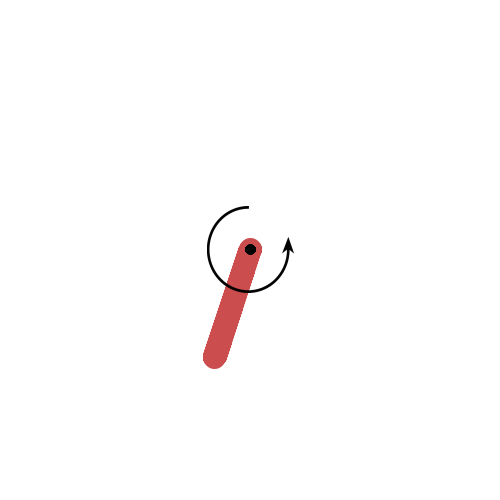

In [6]:
env = gym.make('Pendulum-v1',render_mode="rgb_array", g=9.81)
state, _ = env.reset()
done = False
total_reward = 0
steps = 0
frames = []
for i in range(100):
    action = env.action_space.sample()
    next_state, reward, terminal, truncated, _ = env.step(action)
    done = terminal or truncated
    frame = env.render()
    frames.append(frame)
    state = next_state
    steps += 1
print("Episode:",1," Total Reward:",total_reward," Steps:",steps)
env.close()
imageio.mimsave('pendulum_env.gif', frames, fps=30)
Image(filename='pendulum_env.gif')

## **Desarrollo del algortimo DDPG**

<img src="https://raw.githubusercontent.com/cdavid2804/test-1/main/DDPG.png" alt="DDPG_Algorithm" width="650"/>

### **1. Función de ruido: Proceso de Ornstein-Uhlenbeck (OU)**
Esta función de ruido está descrita por la siguiente ecuación estocástica:

- $dX(t)=\theta(\mu - X(t))dt + \sigma dW(t)$
- $W(t+\Delta t)-W(t)\backsim \mathcal{N}(0,\Delta t) $

In [7]:
x_prev = None
def ou_noise_initialize(size, mu=0, theta=0.15, sigma=0.2, dt=1e-2, x0=None):
    global x_prev
    x_prev = x0 if x0 is not None else np.zeros(size)
def ou_noise_sample(size, mu=0, theta=0.15, sigma=0.2, dt=1e-2):
    global x_prev
    if x_prev is None:
        raise ValueError("Error, inicializar ou_noise_initialize function.")
    x = x_prev + theta*(mu - x_prev)*dt + sigma*np.sqrt(dt)*np.random.normal(size=size)
    x_prev = x
    return x

### **2. Crear redes neuronales: Actor y Crítico**

In [8]:

# red actor
def build_actor_network():
  input = tf.keras.layers.Input(shape=[num_states]) # capa de entrada
  x = tf.keras.layers.Dense(100, activation='relu')(input) # primera capa oculta
  x = tf.keras.layers.Dense(100, activation='relu')(x) # segunda capa oculta
  output = tf.keras.layers.Dense(num_actions, activation='tanh')(x) # capa de salida
  output = output * upper_bound # upper_bound valor maximo de accion, rescala la funcion
  model = tf.keras.models.Model(input, output)
  return model


#red critica
def build_critic_network():
  state_input = tf.keras.layers.Input(shape=[num_states]) #capa de entrada (estados)
  x = tf.keras.layers.Dense(16, activation='relu')(state_input) # primera capa oculta
  state_out = tf.keras.layers.Dense(32, activation='relu')(x) #salida (estados)

  #entrada de la accion
  action_input = tf.keras.layers.Input(shape=[num_actions]) # capa de entrada (acciones)
  action_out = tf.keras.layers.Dense(32, activation='relu')(action_input) # salida (acciones)

  # concadena las 2 salidas
  common = tf.keras.layers.Concatenate()([state_out, action_out]) # concadena la 2 salidas
  out = tf.keras.layers.Dense(100, activation='relu')(common)
  out = tf.keras.layers.Dense(100, activation='relu')(out)
  output = tf.keras.layers.Dense(1)(out)
  model = tf.keras.models.Model([state_input, action_input], output)
  return model


### **3. Creación y entrenamiento del modelo**

#### Clase Agente DDPG

In [9]:
class DDPGAgent:
  def __init__(self, critic_network, critic_optimizer, actor_network, actor_optimizer, target_critic_network, target_actor_network):
    self.critic_network = critic_network
    self.critic_optimizer = critic_optimizer
    self.actor_network = actor_network
    self.actor_optimizer = actor_optimizer
    self.target_critic_network = target_critic_network
    self.target_actor_network = target_actor_network

#### Repetición de experiencias

In [10]:
@tf.function

def update_parameters(states, actions, q_targets, agent):
  with tf.GradientTape() as tape:
    q_values = agent.critic_network([states, actions], training=True) # calcula valores que predice red critica
    critic_loss = tf.reduce_mean(tf.square(q_targets - q_values)) # calcula perdida
  critic_grads = tape.gradient(critic_loss, agent.critic_network.trainable_variables) #obtiene gradiente
  critic_grads, _ = tf.clip_by_global_norm(critic_grads, 1.0) #limita crecimiento de gradientes
  agent.critic_optimizer.apply_gradients(zip(critic_grads, agent.critic_network.trainable_variables))

  with tf.GradientTape() as tape:
    actions_pred = agent.actor_network(states, training=True)
    q_values = agent.critic_network([states, actions_pred], training=True)
    actor_loss = -tf.reduce_mean(q_values)
  actor_grads = tape.gradient(actor_loss, agent.actor_network.trainable_variables)
  actor_grads,_ = tf.clip_by_global_norm(actor_grads, 1.0) #limita calculo de gradientes hasta 1
  agent.actor_optimizer.apply_gradients(zip(actor_grads, agent.actor_network.trainable_variables))# optimizador actualiza los pesos

In [11]:
def experience_replay(buffer, batch_size, gamma, agent):
  if len(buffer) < batch_size:
    return
  minibatch = random.sample(buffer, batch_size)
  #extrae estados, acciones, recompensas y done
  states, actions, rewards, next_states, dones = zip(*minibatch)
  states = tf.convert_to_tensor(np.vstack(states))
  actions = tf.convert_to_tensor(np.vstack(actions))
  rewards = np.vstack(rewards)
  next_states = tf.convert_to_tensor(np.vstack(next_states))
  dones = np.vstack(dones) #np.vstack extrae los estados de forma ordenada

  next_actions = agent.target_actor_network(next_states)
  q_values_next = agent.target_critic_network([next_states, next_actions]) #salida real y se compar con q
  q_targets = rewards + gamma * q_values_next * (1 - dones)
  update_parameters(states, actions, q_targets, agent)

#### Actualización de los pesos de las redes objetivo

In [12]:
#formula de actualizacion suavizada
def update_target_network(target_model, model, tau):
  target_model_weights = target_model.get_weights() #extrae los pesos de la r ed objetivo
  model_weights = model.get_weights()#extrae los pesos de la red principal

  for i in range(len(target_model_weights)):
    target_model_weights[i] = model_weights[i] * tau + target_model_weights[i] * (1 - tau)
  target_model.set_weights(target_model_weights)

#### Política para elegir la acción

In [13]:
def policy(state, noise, agent):
  action_pred = agent.actor_network(state) #red actor predice la accion
  action_noise = action_pred.numpy()[0] + noise #ruido
  action = np.clip(action_noise, lower_bound, upper_bound)
  return action

#### Entrenamiento del Agente

In [ ]:
env = gym.make("Pendulum-v1", render_mode='human')
np.random.seed(42)
tf.random.set_seed(54)

#definir hiperparametros
gamma = 0.995
batch_size = 64
buffer_size = 50000
num_episodes = 200
tau = 0.005
acumulate_reward = 0
average_reward = 0
episode_reward = deque(maxlen=num_episodes)
buffer = deque(maxlen=buffer_size)

#inicializar la funcion de ruido
ou_noise_initialize(size=num_actions)

#crear las redes neuronales ACTOR-CRITICO
actor_network = build_actor_network() # red actor principal
critic_network = build_critic_network() # red critica principal
target_actor_network = build_actor_network() # red actor objetivo
target_critic_network = build_critic_network() # red critica objetivo

#inicializar los pesos de las redes objetivos
target_actor_network.set_weights(actor_network.get_weights())
target_critic_network.set_weights(critic_network.get_weights())

#optimizadores
actor_lr = 0.001 # tasa de aprendizaje (actor)
critic_lr = 0.001 # tasa de aprendizaje (critica)
critic_optimizer = keras.optimizers.Adam(critic_lr)
actor_optimizer = keras.optimizers.Adam(actor_lr)

agent = DDPGAgent(critic_network, critic_optimizer, actor_network, actor_optimizer, target_critic_network, target_actor_network)

#funcion de recompensa
def reward_function(next_state, action):

  value = 0.1
  action_value = 0.01
  theta = np.arctan2(next_state[1], next_state[0])
  theta_dot = next_state[2]
  action_val = action[0]
  reward_value = -(theta**2 + value * theta_dot**2 + action_value *action_val**2)
  return reward_value
  

for episode in range(1, num_episodes+1):
  state,_ = env.reset()
  done = False
  total_reward = 0
  steps = 0
  accumalate_reward = 0
  while not done:
    noise = ou_noise_sample(size=num_actions)
    action = policy(np.array([state]), noise, agent)
    next_state, _, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    reward = reward_function(next_state, action)
    steps += 1
    buffer.append((np.array([state]), action, reward, np.array([next_state]), done))
    total_reward += reward
    experience_replay(buffer, batch_size, gamma, agent)
    update_target_network(target_actor_network, actor_network, tau)
    update_target_network(target_critic_network, critic_network, tau)
    state = next_state
    episode_reward.append((episode, total_reward))
    accumalate_reward += total_reward
    average_reward = accumalate_reward / episode
    episode_reward.append((episode, total_reward))
    print(f"Episode:{episode} | Total reward:{total_reward:.3f} | Average reward:{average_reward:.3f} | Steps:{steps}")
env.close()

Episode:1 | Total reward:6.513 | Average reward:6.513 | Steps:1
Episode:1 | Total reward:13.121 | Average reward:19.633 | Steps:2
Episode:1 | Total reward:19.898 | Average reward:39.531 | Steps:3
Episode:1 | Total reward:26.922 | Average reward:66.452 | Steps:4
Episode:1 | Total reward:34.273 | Average reward:100.725 | Steps:5
Episode:1 | Total reward:42.031 | Average reward:142.756 | Steps:6
Episode:1 | Total reward:50.269 | Average reward:193.025 | Steps:7
Episode:1 | Total reward:59.049 | Average reward:252.074 | Steps:8
Episode:1 | Total reward:68.413 | Average reward:320.486 | Steps:9
Episode:1 | Total reward:77.532 | Average reward:398.019 | Steps:10
Episode:1 | Total reward:86.199 | Average reward:484.217 | Steps:11
Episode:1 | Total reward:94.497 | Average reward:578.714 | Steps:12
Episode:1 | Total reward:102.510 | Average reward:681.224 | Steps:13
Episode:1 | Total reward:110.317 | Average reward:791.540 | Steps:14
Episode:1 | Total reward:117.992 | Average reward:909.532 | S

### **Guardar la política entrenada**

In [ ]:
actor_network.save('DDPGagent.keras')

## **Graficar la recompensa total y la recompensa promedio**

In [ ]:
episodeReward = np.array(episode_reward)
episodes = episodeReward[:,0]
# Total rewards
rewards = episodeReward[:,1]
# Mean rewards
meanRewards = np.zeros(len(episodes))

for i in range(len(episodes)):
    if i == 0:
        meanRewards[0] = rewards[0]
    else:
        meanRewards[i] = np.mean(rewards[:i])
plt.figure(figsize=(7, 6))
plt.plot(episodes, rewards, label=r"Total Reward", linewidth=2, color='purple')
plt.plot(episodes, meanRewards, label=r"Average Reward", linewidth=2, color='orange')
plt.xlabel("Episode number")
plt.ylabel("Episode reward")
plt.title("Deep Deterministic Policy Gradient (DDPG)")
plt.xlim(0, num_episodes)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.grid()
plt.legend()
plt.show()

## **Probar la política entrenada**

In [ ]:
# Cargar una política entrenada
actor_network = keras.models.load_model('DDPGagent.keras')

In [ ]:
env = gym.make("Pendulum-v1", render_mode="rgb_array")
state, _ = env.reset()
done = False
num_steps = 500
frames = []
for steps in range(1,num_steps+1):
    action = actor_network(np.array([state])).numpy()[0]
    next_state, _, _, _, _ = env.step(action)
    frame = env.render()
    frames.append(frame)
    state = next_state
    if done: break
env.close()
imageio.mimsave('PendulumTest.gif', frames, fps=50)
Image(filename='PendulumTest.gif')